In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import sklearn

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram

In [3]:
#import dataset and read it into DataFrame
df= pd.read_csv("wine-quality-white-and-red.csv")

In [4]:
#view first 5 rows of dataset
df.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [5]:
#total number of wine samples and columns
df.shape

(6497, 13)

In [6]:
#summary of DataFrame with column statistics
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6497 non-null   float64
 2   volatile acidity      6497 non-null   float64
 3   citric acid           6497 non-null   float64
 4   residual sugar        6497 non-null   float64
 5   chlorides             6497 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6497 non-null   float64
 10  sulphates             6497 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB
None
       fixed acidity  volatile acidity  citric acid  resid

In [7]:
#convert column to float
df['quality']= df['quality'].astype(float)

In [8]:
#describe the type column
df.describe (include='object')

,type
count,6497
unique,2
top,white
freq,4898


In [9]:
#mapping numerical values to labels in type column
df['type_numeric']= df['type'].map({'red': 1, 'white': 2})

In [10]:
#convert column to float
df['type_numeric']= df['type_numeric'].astype(float)

In [11]:
#show column types
print(df.dtypes)

type                     object
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                 float64
type_numeric            float64
dtype: object


In [12]:
#dropping type coloumn
df= df.drop('type', axis=1)
print(df)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.0             0.270         0.36            20.7      0.045   
1               6.3             0.300         0.34             1.6      0.049   
2               8.1             0.280         0.40             6.9      0.050   
3               7.2             0.230         0.32             8.5      0.058   
4               7.2             0.230         0.32             8.5      0.058   
...             ...               ...          ...             ...        ...   
6492            6.2             0.600         0.08             2.0      0.090   
6493            5.9             0.550         0.10             2.2      0.062   
6494            6.3             0.510         0.13             2.3      0.076   
6495            5.9             0.645         0.12             2.0      0.075   
6496            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

In [13]:
#dropping output variable coloumn for unsupervised learning
df= df.drop('quality', axis=1)
print(df)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.0             0.270         0.36            20.7      0.045   
1               6.3             0.300         0.34             1.6      0.049   
2               8.1             0.280         0.40             6.9      0.050   
3               7.2             0.230         0.32             8.5      0.058   
4               7.2             0.230         0.32             8.5      0.058   
...             ...               ...          ...             ...        ...   
6492            6.2             0.600         0.08             2.0      0.090   
6493            5.9             0.550         0.10             2.2      0.062   
6494            6.3             0.510         0.13             2.3      0.076   
6495            5.9             0.645         0.12             2.0      0.075   
6496            6.0             0.310         0.47             3.6      0.067   

      free sulfur dioxide  

In [14]:
# show total NaN values in each column
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
type_numeric            0
dtype: int64


In [15]:
#scale dataset by dropping labels
scaler =StandardScaler()

features =scaler.fit(df)
features =features.transform(df)

# Convert to pandas Dataframe
scaled_df =pd.DataFrame(features,columns=df.columns)
# Print the scaled data
scaled_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type_numeric
0,-0.166089,-0.423183,0.284686,3.206929,-0.314975,0.815565,0.959976,2.102214,-1.359049,-0.546178,-1.418558,0.571367
1,-0.706073,-0.240949,0.147046,-0.807837,-0.200790,-0.931107,0.287618,-0.232332,0.506915,-0.277351,-0.831615,0.571367
2,0.682458,-0.362438,0.559966,0.306208,-0.172244,-0.029599,-0.331660,0.134525,0.258120,-0.613385,-0.328521,0.571367
3,-0.011808,-0.666161,0.009406,0.642523,0.056126,0.928254,1.243074,0.301278,-0.177272,-0.882212,-0.496219,0.571367
4,-0.011808,-0.666161,0.009406,0.642523,0.056126,0.928254,1.243074,0.301278,-0.177272,-0.882212,-0.496219,0.571367


In [16]:
X=scaled_df.values

In [17]:
#heirarchical clustering linkage methods
complete_clustering = linkage(scaled_df, method="complete", metric="euclidean")
average_clustering = linkage(scaled_df, method="average", metric="euclidean")
single_clustering = linkage(scaled_df, method="single", metric="euclidean")

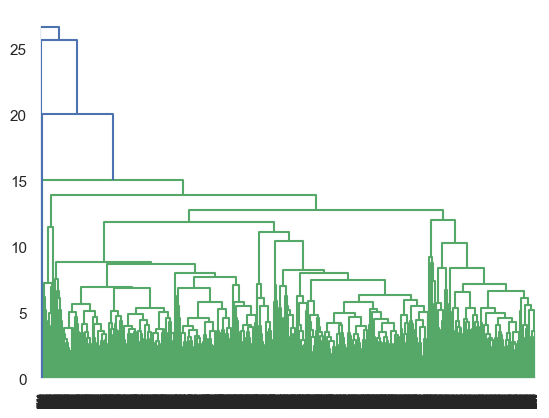

In [18]:
#dendrogram of Complete linkage
dendrogram(complete_clustering)
plt.show()

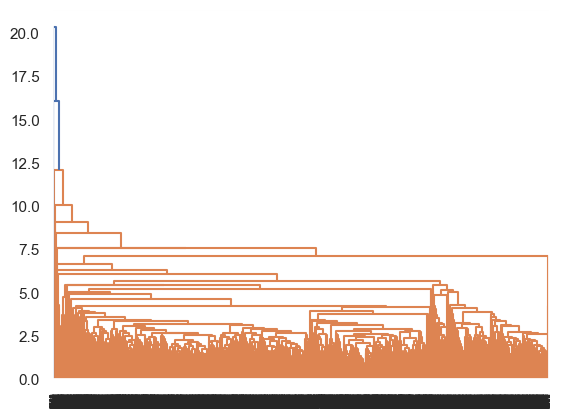

In [19]:
#dendrogram of Average linkage
dendrogram(average_clustering)
plt.show()

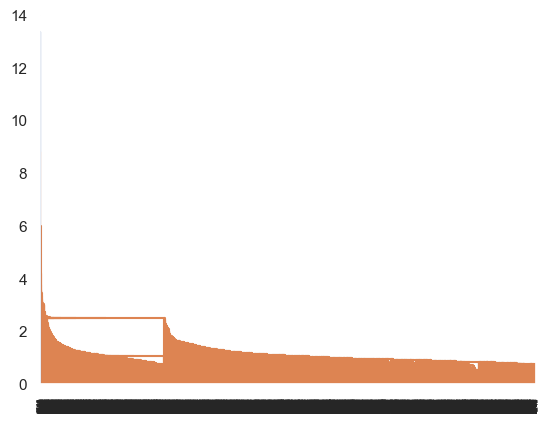

In [20]:
#dendrogram of Single linkage
dendrogram(single_clustering)
plt.show()

In [21]:
#initialize and fit KMeans 
kmeans=KMeans(n_clusters=3)
kmeans.fit(X)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [22]:
#value of cluster center
kmeans.cluster_centers_

array([[-0.18469105, -0.34351804,  0.27595163,  1.20782149, -0.07871017,
         0.84492928,  0.95806215,  0.76409065, -0.38685971, -0.25314799,
        -0.79676306,  0.56645584],
       [ 0.86389074,  1.16106251, -0.33421778, -0.61565414,  0.90867283,
        -0.83348733, -1.23342327,  0.69399656,  0.57708888,  0.86144769,
        -0.06935864, -1.73997558],
       [-0.34003296, -0.39723311,  0.00328888, -0.43266491, -0.43013517,
        -0.09011043,  0.04997708, -0.84545405, -0.06188945, -0.29580777,
         0.53632787,  0.56289657]])

In [23]:
#index of clusters for samples
kmeans.labels_

array([0, 2, 2, ..., 1, 1, 1], dtype=int32)

In [24]:
#minimize features using PCA
pca=PCA(n_components=2)

reduced_X=pd.DataFrame(data=pca.fit_transform(X),columns=['PCA1','PCA2'])

#Reduced Features
reduced_X.head()

,PCA1,PCA2
0,2.185179,3.529983
1,0.247707,-0.553177
2,0.380592,0.365447
3,1.735882,0.929351
4,1.735882,0.929351


In [25]:
#reduce cluster centers with PCA
centers=pca.transform(kmeans.cluster_centers_)
centers

array([[ 1.52530116,  1.59218812],
       [-3.15769216,  0.3509839 ],
       [ 0.70963308, -1.18382856]])

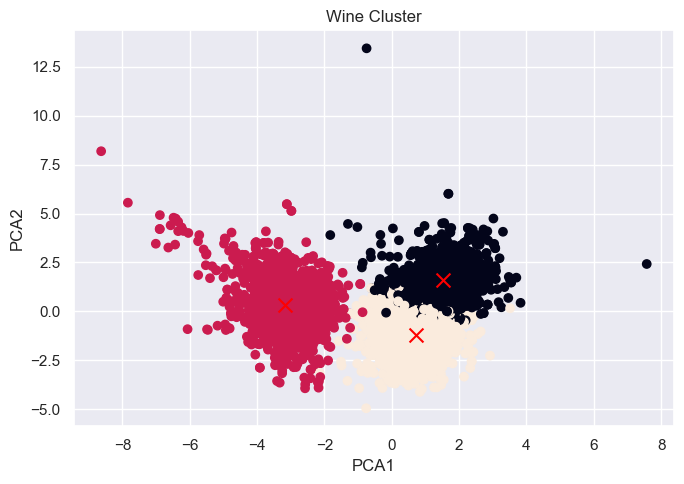

In [26]:
#scatterplot of reduced data
plt.figure(figsize=(7,5)) 
plt.scatter(reduced_X['PCA1'],reduced_X['PCA2'],c=kmeans.labels_)
plt.scatter(centers[:,0],centers[:,1],marker='x',s=100,c='red')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('Wine Cluster')
plt.tight_layout()

In [27]:
from sklearn.manifold import TSNE

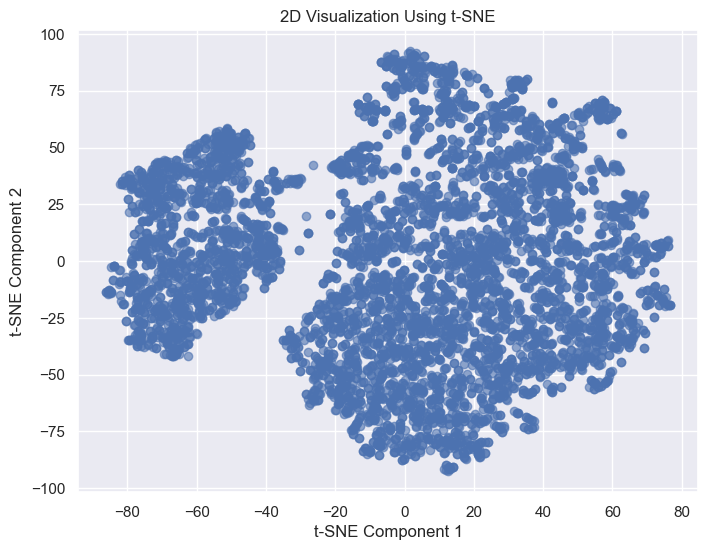

In [28]:
#TSNE visual
tsne = TSNE(n_components=2, random_state=42)
df_tsne = tsne.fit_transform(scaled_df)

plt.figure(figsize=(8, 6))
plt.scatter(df_tsne[:, 0], df_tsne[:, 1], alpha=0.6)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("2D Visualization Using t-SNE")
plt.show()

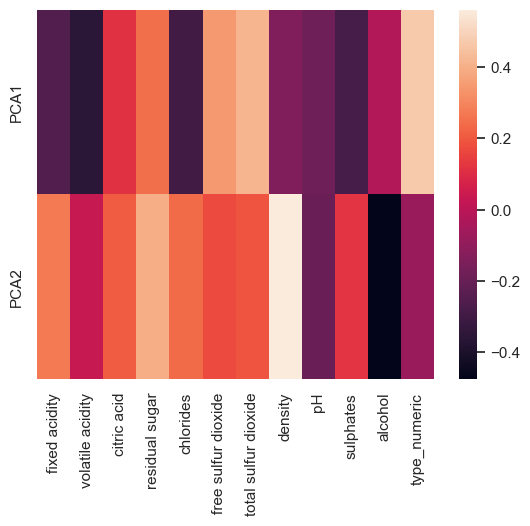

In [29]:
#Heatmap of Feature's effects on PCA components
component_df=pd.DataFrame(pca.components_,index=['PCA1',"PCA2"],columns=df.columns)
sns.heatmap(component_df)
plt.show()

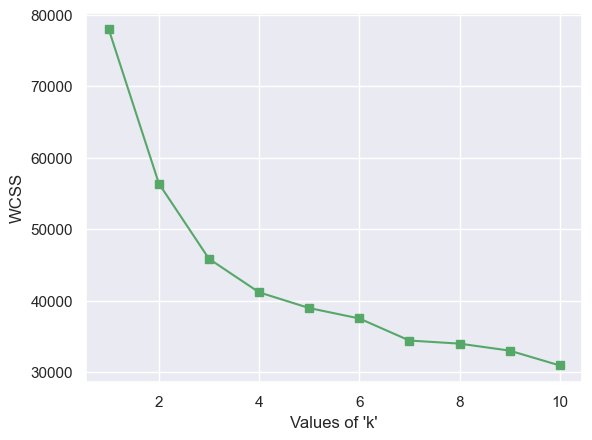

In [30]:
#use Elbow method to determine number of clusters
wcss = {} 
for i in range(1, 11): 
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X) 
    wcss[i] = kmeans.inertia_
    
plt.plot(wcss.keys(), wcss.values(), 'gs-')
plt.xlabel("Values of 'k'")
plt.ylabel('WCSS')
plt.show()

In [31]:
from sklearn.cluster import AgglomerativeClustering

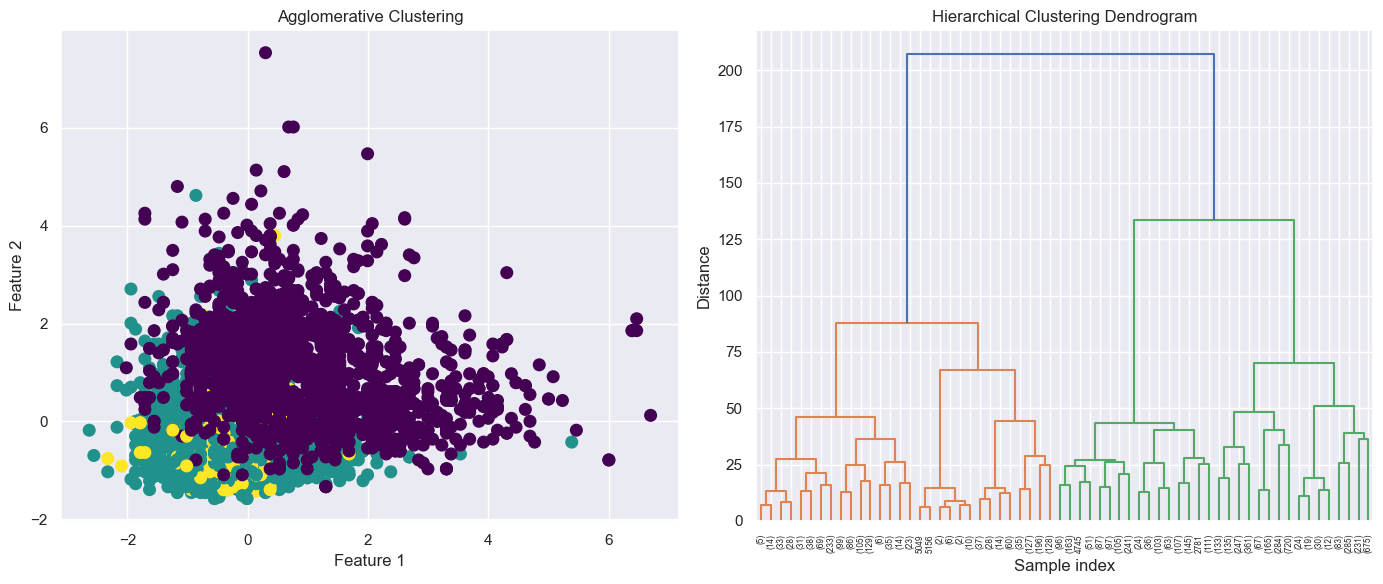

In [32]:
clustering = AgglomerativeClustering(n_clusters=3)
labels = clustering.fit_predict(X)

agg = AgglomerativeClustering(distance_threshold=0, n_clusters=None)
agg.fit(X)


def plot_dendrogram(model, **kwargs):
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)

    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]).astype(float)
    dendrogram(linkage_matrix, **kwargs)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=70)
ax1.set_title("Agglomerative Clustering")
ax1.set_xlabel("Feature 1")
ax1.set_ylabel("Feature 2")

plt.sca(ax2)
plot_dendrogram(agg, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")

plt.tight_layout()
plt.show()